Dans ce notebook, nous utilisons l’architecture **DenseNet121** (*Densely Connected Convolutional Network*) pour la classification des taxons de plantes par apprentissage par transfert (*transfer learning*). DenseNet121 repose sur un principe de **connexions denses**, où chaque couche convolutionnelle reçoit non seulement l’information provenant de la couche précédente, mais également les caractéristiques extraites par toutes les couches antérieures du réseau. Cette organisation améliore la circulation de l’information et du gradient tout en favorisant la réutilisation des caractéristiques apprises. Elle permet notamment de conserver des détails visuels fins, tels que les textures, les nervures ou les variations morphologiques des feuilles, qui sont importants pour distinguer des espèces proches. Les poids pré-entraînés sur ImageNet sont utilisés comme base d’apprentissage, puis la couche de classification finale est remplacée afin de correspondre au nombre de taxons du jeu de données. Une étape de *fine-tuning* est ensuite réalisée pour adapter les représentations apprises aux caractéristiques spécifiques des plantes étudiées.


# Chargement du modèle sauvegardé

Si l'entraînement du modèle a déjà été réalisé et que les poids ont été sauvegardés sur Google Drive, il est possible de recharger directement le modèle afin d'éviter de relancer l'entraînement. Le modèle ainsi chargé permet ensuite de reproduire les évaluations, générer les prédictions et visualiser les résultats (classification report, matrice de confusion, erreurs de classification et Grad-CAM).

In [ ]:
# # ============================================================
# # CHARGEMENT MODELE DENSENET121 SAUVEGARDE
# # ============================================================

# import torch
# import torch.nn as nn
# import pickle
# import os

# from torchvision import models


# MODEL_DIR = "/content/drive/MyDrive/Projet_Plantes/Modèles CNN/DenseNet121"


# # Chargement du LabelEncoder

# with open(
#     os.path.join(
#         MODEL_DIR,
#         "densenet121_label_encoder.pkl"
#     ),
#     "rb"
# ) as f:

#     encoder = pickle.load(f)



# # Nombre de classes

# num_classes = len(
#     encoder.classes_
# )

# print(
#     "Nombre de classes :",
#     num_classes)

# # Reconstruction de l'architecture DenseNet121

# model = models.densenet121(
#     weights=None)


# # Remplacement du classifieur

# model.classifier = nn.Linear(
#     model.classifier.in_features,
#     num_classes)

# # Chargement des poids

# model.load_state_dict(
#     torch.load(
#         os.path.join(
#             MODEL_DIR,
#             "densenet121_taxons_finetuned.pth"
#         ),
#         map_location=device))



# # Passage sur GPU/CPU

# model = model.to(device)

# # Mode évaluation

# model.eval()

# print("✅ DenseNet121 chargé avec succès")

# Importation des données

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights

from PIL import Image

from tqdm.notebook import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from google.colab import drive



# Seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


# Drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 2. ACCES DATASET
# ============================================================

BASE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Projet_Plantes"
)


print(
    "Projet accessible :",
    BASE_PROJECT_DIR.exists()
)


path = "/content/drive/MyDrive/Projet_Plantes"

# création du chemin (variable path) vers le dossier Projet_Plantes
os.listdir('/content/drive/MyDrive')
os.path.exists('/content/drive/MyDrive/Projet_Plantes')
path = "/content/drive/MyDrive/Projet_Plantes"


# décompression de taxons
if not os.path.exists('/content/TAXONS/all'):
    print("Décompression de TAXONS en cours... (quelques minutes)")
    with zipfile.ZipFile(path + "/TAXONS.zip", 'r') as z:
        z.extractall('/content/TAXONS')
    print("TAXONS décompressé ✓")
else:
    print("TAXONS déjà décompressé ✓")
path_bdd = '/content/TAXONS/all/'


Projet accessible : True
Décompression de TAXONS en cours... (quelques minutes)
TAXONS décompressé ✓


## Chargement des splits

In [ ]:
# ============================================================
# 3. CHARGEMENT DES SPLITS
# ============================================================


SPLIT_DIR = BASE_PROJECT_DIR / "V2_TAXONS_CLEAN_SPLITS"
df_train = pd.read_csv(
    SPLIT_DIR / "train.csv")
df_val = pd.read_csv(
    SPLIT_DIR / "val.csv")
df_test = pd.read_csv(
    SPLIT_DIR / "test.csv")



print("="*50)

print(
    f"Train : {len(df_train):,}")

print(
    f"Val   : {len(df_val):,}")

print(
    f"Test  : {len(df_test):,}")

print(df_train.columns)
display(df_train.head())

Train : 67,377
Val   : 14,370
Test  : 14,418
Index(['chemin', 'taxon_label', 'source_dataset', 'group_id'], dtype='object')


,chemin,taxon_label,source_dataset,group_id
0,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,0
1,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,1
2,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,2
3,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,3
4,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,4


In [ ]:
# ============================================================
# 4. CORRECTION CHEMINS
# ============================================================

def corriger_chemin(chemin):

    nom_image = os.path.basename(chemin)

    classe = os.path.basename(
        os.path.dirname(chemin))

    return (
        f"/content/TAXONS/all/"
        f"{classe}/{nom_image}")

for df in [
    df_train,
    df_val,
    df_test]:

    df["chemin"] = df["chemin"].apply(
        corriger_chemin)

print(
    df_train["chemin"].iloc[0])
print(
    os.path.exists(
        df_train["chemin"].iloc[0]))

/content/TAXONS/all/apple/npd_apple_009115.jpg
True


## encodage + classe weight

In [ ]:
# ============================================================
# 5. LABEL ENCODING
# ============================================================
encoder = LabelEncoder()

df_train["label_idx"] = encoder.fit_transform(
    df_train["taxon_label"])
df_val["label_idx"] = encoder.transform(
    df_val["taxon_label"])
df_test["label_idx"] = encoder.transform(
    df_test["taxon_label"])
num_classes = len(
    encoder.classes_)
print(
    "Nombre de classes :",
    num_classes)

Nombre de classes : 14


In [ ]:
classes = np.unique(
    df_train["label_idx"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label_idx"])
print(class_weights)
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu")

print(device)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

[0.70237053 3.0421257  1.55950838 0.75587292 0.75056813 1.24679867
 1.57946927 1.40556158 0.98397932 3.13323103 1.34468926 3.17038396
 1.53220085 0.26615656]
cuda


In [ ]:
# ============================================================
# 6. DATASET
# ============================================================


class PlantDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["chemin"]
        label = self.df.iloc[idx]["label_idx"]
        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(
                image)
        return image, label

# DenseNet121

## Préparation du modèle

In [ ]:
# ============================================================
# 7. TRANSFORMATIONS DENSENET
# ============================================================


weights = DenseNet121_Weights.DEFAULT
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(
        p=0.5),
    transforms.RandomRotation(
        20),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406],
        std=[
            0.229,
            0.224,
            0.225])])

transform_test = transforms.Compose([

    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406],
        std=[
            0.229,
            0.224,
            0.225])])

In [ ]:
# ============================================================
# 8. DATALOADERS
# ============================================================


dataset_train = PlantDataset(
    df_train,
    transform_train)
dataset_val = PlantDataset(
    df_val,
    transform_test)
dataset_test = PlantDataset(
    df_test,
    transform_test)

BATCH_SIZE = 32
dataloader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True)
dataloader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False)
dataloader_test = DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False)

In [ ]:
# ============================================================
# 9. MODELE DENSENET121
# ============================================================


model = models.densenet121(
    weights=weights)

# Gel des poids convolutionnels

for param in model.parameters():

    param.requires_grad = False


# Remplacement du classifieur
num_features = (
    model.classifier.in_features)
model.classifier = nn.Linear(
    num_features,
    num_classes)
model = model.to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 241MB/s]


Linear(in_features=1024, out_features=14, bias=True)


In [ ]:
X_batch, y_batch = next(
    iter(dataloader_train))
print(
    X_batch.shape)
print(
    y_batch.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
# ============================================================
# 11. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3)

## Entrainement du modèle
Pendant cette première phase :

*  le backbone DenseNet est gelé
*  seul le classifieur final apprend les classes de taxons


In [ ]:
# ============================================================
# 12. EVALUATION
# ============================================================


def evaluate(loader):

    model.eval()


    predictions = []

    true_labels = []

    with torch.no_grad():


        for X, y in loader:

            X = X.to(device)

            outputs = model(
                X
            )
            pred = torch.argmax(
                outputs,
                dim=1
            )
            predictions.extend(
                pred.cpu().numpy() )
            true_labels.extend(
                y.numpy())



    predictions = np.array(
        predictions)
    true_labels = np.array(
        true_labels)
    accuracy = accuracy_score(
        true_labels,
        predictions)

    f1 = f1_score(
        true_labels,
        predictions,
        average="macro")
    return {
        "accuracy": accuracy,

        "f1": f1
    }

In [ ]:
# ============================================================
# 13. ENTRAINEMENT INITIAL OPTIMISE
# ============================================================

# Historique apprentissage initial

history = {

    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


epochs = 10


for epoch in range(epochs):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    loss_total = 0

    correct_train = 0
    total_train = 0


    progress_bar = tqdm(
        dataloader_train,
        desc=f"Epoch {epoch+1}/{epochs}"
    )


    for X_batch, y_batch in progress_bar:


        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        optimizer.zero_grad()


        predictions = model(
            X_batch
        )


        loss = criterion(
            predictions,
            y_batch
        )


        loss.backward()

        optimizer.step()


        loss_total += loss.item()



        # Accuracy train

        predicted_classes = torch.argmax(
            predictions,
            dim=1
        )


        correct_train += (
            predicted_classes == y_batch
        ).sum().item()


        total_train += y_batch.size(0)



        progress_bar.set_postfix(
            loss=loss.item()
        )



    train_loss = (
        loss_total /
        len(dataloader_train))


    train_accuracy = (
        correct_train /
        total_train
    )



    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss = 0

    correct_val = 0
    total_val = 0


    with torch.no_grad():


        for X_val, y_val in dataloader_val:


            X_val = X_val.to(device)
            y_val = y_val.to(device)


            pred = model(
                X_val)


            loss = criterion(
                pred,
                y_val)


            val_loss += loss.item()



            # Accuracy validation

            predicted_classes = torch.argmax(
                pred,
                dim=1)


            correct_val += (
                predicted_classes == y_val
            ).sum().item()


            total_val += y_val.size(0)



    val_loss = (
        val_loss /
        len(dataloader_val))


    val_accuracy = (
        correct_val /
        total_val)



    # ========================================================
    # Sauvegarde historique
    # ========================================================

    history["train_loss"].append(
        train_loss)

    history["val_loss"].append(
        val_loss)

    history["train_accuracy"].append(
        train_accuracy)

    history["val_accuracy"].append(
        val_accuracy)



    # Scheduler

    scheduler.step(
        val_loss)



    print(
        f"""
Epoch {epoch+1}/{epochs}

Train loss :
{train_loss:.4f}

Val loss :
{val_loss:.4f}


Train accuracy :
{train_accuracy:.4f}


Val accuracy :
{val_accuracy:.4f}

"""
    )

Epoch 1/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 1/10

Train loss :
0.2952

Val loss :
0.1035


Train accuracy :
0.9241


Val accuracy :
0.9705




Epoch 2/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 2/10

Train loss :
0.0972

Val loss :
0.0797


Train accuracy :
0.9648


Val accuracy :
0.9759




Epoch 3/10:   0%|          | 0/2106 [00:00<?, ?it/s]

...


Epoch 8/10

Train loss :
0.0529

Val loss :
0.0459


Train accuracy :
0.9753


Val accuracy :
0.9843




Epoch 9/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 9/10

Train loss :
0.0526

Val loss :
0.0711


Train accuracy :
0.9758


Val accuracy :
0.9765




Epoch 10/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 10/10

Train loss :
0.0508

Val loss :
0.0482


Train accuracy :
0.9759


Val accuracy :
0.9839




In [ ]:
metrics_train = evaluate(
    dataloader_train)
metrics_val = evaluate(
    dataloader_val)
metrics_test = evaluate(
    dataloader_test)



print("===== TRAIN =====")
print(
    "Accuracy :",
    metrics_train["accuracy"])
print(
    "F1 :",
    metrics_train["f1"])

print("\n===== VALIDATION =====")
print(
    "Accuracy :",
    metrics_val["accuracy"])
print(
    "F1 :",
    metrics_val["f1"])

print("\n===== TEST =====")
print(
    "Accuracy :",
    metrics_test["accuracy"])
print(
    "F1 :",
    metrics_test["f1"])

===== TRAIN =====
Accuracy : 0.9832435400804429
F1 : 0.9853091526978631

===== VALIDATION =====
Accuracy : 0.9839248434237996
F1 : 0.9853606470945432

===== TEST =====
Accuracy : 0.9862671660424469
F1 : 0.9866953197554736


## Fine tuning

In [ ]:
# ============================================================
# Fine tuning
# ============================================================


# Historique du fine tuning

history_ft = {

    "train_loss": [],

    "val_loss": [],

    "train_accuracy": [],

    "val_accuracy": []}


In [ ]:
# ============================================================
# 15. FINE TUNING DENSENET
# ============================================================
for name, param in model.named_parameters():
    if "denseblock4" in name:

        param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,
        model.parameters()),
    lr=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.1,

    patience=3)

In [ ]:
# ============================================================
# 16. ENTRAINEMENT FINE TUNING
# ============================================================


epochs_ft = 5


for epoch in range(epochs_ft):
    model.train()
    loss_total = 0
    progress_bar = tqdm(
        dataloader_train,
        desc=f"Fine tuning Epoch {epoch+1}/{epochs_ft}" )



    for X_batch, y_batch in progress_bar:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)



        optimizer.zero_grad()
        predictions = model(
            X_batch)
        loss = criterion(
            predictions,
            y_batch)

        loss.backward()
        optimizer.step()
        loss_total += loss.item()





    # ========================================================
    # Validation
    # ========================================================


    model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_val, y_val in dataloader_val:



            X_val = X_val.to(device)

            y_val = y_val.to(device)



            pred = model(
                X_val)



            loss = criterion(
                pred,
                y_val)



            val_loss += loss.item()



    train_loss = loss_total / len(
        dataloader_train)


    val_loss = val_loss / len(
        dataloader_val)



    # ========================================================
    # Accuracy train / validation
    # ========================================================


    train_metrics = evaluate(
        dataloader_train)


    val_metrics = evaluate(
        dataloader_val)



    # ========================================================
    # Sauvegarde historique
    # ========================================================


    history_ft["train_loss"].append(
        train_loss)


    history_ft["val_loss"].append(
        val_loss)


    history_ft["train_accuracy"].append(
        train_metrics["accuracy"])


    history_ft["val_accuracy"].append(
        val_metrics["accuracy"])



    scheduler.step(
        val_loss)



    print(

        f"""
Fine tuning epoch {epoch+1}/{epochs_ft}

Train loss :
{train_loss:.4f}

Val loss :
{val_loss:.4f}

Train accuracy :
{train_metrics["accuracy"]:.4f}

Val accuracy :
{val_metrics["accuracy"]:.4f}

""" )

Fine tuning Epoch 1/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 1/5

Train loss :
0.0345

Val loss :
0.0276

Train accuracy :
0.9913

Val accuracy :
0.9897




Fine tuning Epoch 2/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 2/5

Train loss :
0.0221

Val loss :
0.0237

Train accuracy :
0.9932

Val accuracy :
0.9909




Fine tuning Epoch 3/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 3/5

Train loss :
0.0181

Val loss :
0.0144

Train accuracy :
0.9962

Val accuracy :
0.9944




Fine tuning Epoch 4/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 4/5

Train loss :
0.0148

Val loss :
0.0163

Train accuracy :
0.9953

Val accuracy :
0.9943




Fine tuning Epoch 5/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 5/5

Train loss :
0.0109

Val loss :
0.0152

Train accuracy :
0.9968

Val accuracy :
0.9952




In [ ]:
# ============================================================
# 17. FUSION HISTORIQUE ENTRAINEMENT + FINE TUNING
# ============================================================


history_complete = {
    "train_loss":
    history["train_loss"] + history_ft["train_loss"],
    "val_loss":
    history["val_loss"] + history_ft["val_loss"],
   "train_accuracy":
    history["train_accuracy"] + history_ft["train_accuracy"],
    "val_accuracy":
    history["val_accuracy"] + history_ft["val_accuracy"]}


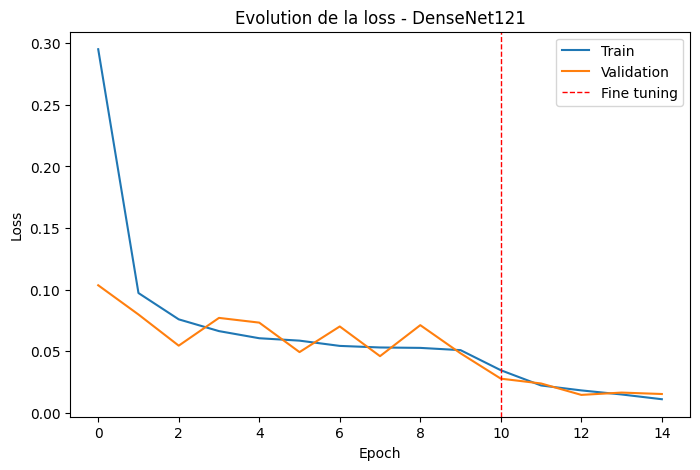

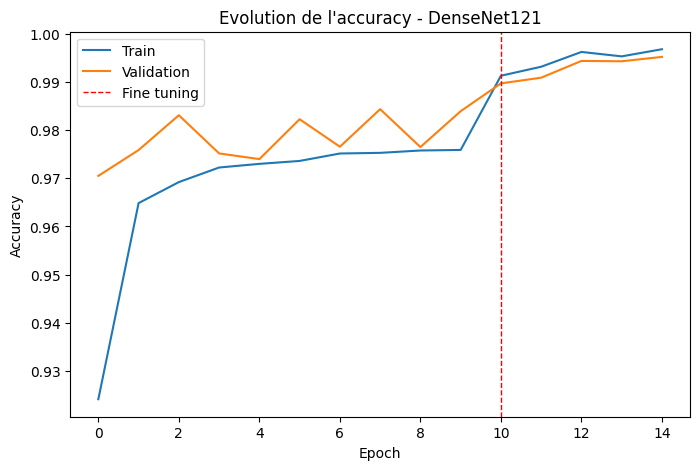

In [ ]:
# ============================================================
# 18. COURBES D'APPRENTISSAGE
# ============================================================

# Evolution Loss
plt.figure(figsize=(8,5))

plt.plot(
    history_complete["train_loss"],
    label="Train")

plt.plot(
    history_complete["val_loss"],
    label="Validation")

# Ligne de séparation entraînement / fine tuning
plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Fine tuning")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolution de la loss - DenseNet121")
plt.legend()
plt.show()


# ============================================================
# Evolution Accuracy
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history_complete["train_accuracy"],
    label="Train")

plt.plot(
    history_complete["val_accuracy"],
    label="Validation")

# Ligne de séparation entraînement / fine tuning
plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Fine tuning")


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolution de l'accuracy - DenseNet121")
plt.legend()
plt.show()




In [ ]:
# ============================================================
# SAUVEGARDE MODELE DENSENET121
# ============================================================

import os
import pickle
import json
import torch


MODEL_DIR = "/content/drive/MyDrive/Projet_Plantes/Modèles CNN/DenseNet121"


# Création du dossier

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# Sauvegarde des poids du modèle

torch.save(
    model.state_dict(),
    os.path.join(
        MODEL_DIR,
        "densenet121_taxons_finetuned.pth"
    )
)



# Sauvegarde du LabelEncoder

with open(
    os.path.join(
        MODEL_DIR,
        "densenet121_label_encoder.pkl"
    ),
    "wb"
) as f:

    pickle.dump(
        encoder,
        f
    )



# Sauvegarde configuration

config = {

    "model": "DenseNet121",

    "num_classes": num_classes,

    "classes": list(
        encoder.classes_
    ),

    "input_size": 224,

    "normalization_mean": [
        0.485,
        0.456,
        0.406
    ],

    "normalization_std": [
        0.229,
        0.224,
        0.225
    ]
}


with open(
    os.path.join(
        MODEL_DIR,
        "densenet121_config.json"
    ),
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


print("✅ DenseNet121 sauvegardé dans :")
print(MODEL_DIR)

print("\nFichiers :")
print(os.listdir(MODEL_DIR))

✅ DenseNet121 sauvegardé dans :
/content/drive/MyDrive/Projet_Plantes/Modèles CNN/DenseNet121

Fichiers :
['densenet121_taxons_finetuned.pth', 'densenet121_label_encoder.pkl', 'densenet121_config.json']


## Résultats

In [ ]:
metrics_train = evaluate(
    dataloader_train)
metrics_val = evaluate(
    dataloader_val)
metrics_test = evaluate(
    dataloader_test)

print("===== TRAIN =====")

print( "Accuracy :",
    metrics_train["accuracy"])
print(
    "F1 :",
    metrics_train["f1"])

print("\n===== VALIDATION =====")

print(
    "Accuracy :",
    metrics_val["accuracy"])

print(
    "F1 :",
    metrics_val["f1"])

print("\n===== TEST =====")
print(
    "Accuracy :",
    metrics_test["accuracy"])
print(
    "F1 :",
    metrics_test["f1"])

===== TRAIN =====
Accuracy : 0.9966308977841103
F1 : 0.9972966983463033

===== VALIDATION =====
Accuracy : 0.9951983298538623
F1 : 0.9954652840323648

===== TEST =====
Accuracy : 0.9956998196698571
F1 : 0.9961456123444627


In [ ]:
# ============================================================
# Evaluation finale Train / Validation / Test
# ============================================================

metrics_train = evaluate(dataloader_train)

metrics_val = evaluate(dataloader_val)

metrics_test = evaluate(dataloader_test)


print("===== TRAIN =====")
print(
    "Accuracy :",
    metrics_train["accuracy"])

print(
    "F1-score :",
    metrics_train["f1"])



print("\n===== VALIDATION =====")
print(
    "Accuracy :",
    metrics_val["accuracy"])

print(
    "F1-score :",
    metrics_val["f1"])

print("\n===== TEST =====")
print(
    "Accuracy :",
    metrics_test["accuracy"])

print(
    "F1-score :",
    metrics_test["f1"])

===== TRAIN =====
Accuracy : 0.996245009424581
F1-score : 0.9969912849374454

===== VALIDATION =====
Accuracy : 0.9951983298538623
F1-score : 0.9954652840323648

===== TEST =====
Accuracy : 0.9956998196698571
F1-score : 0.9961456123444627


In [ ]:
# ============================================================
# 19. PREDICTIONS
# ============================================================


def get_predictions(loader):

    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():


        for images, labels in loader:

            images = images.to(device)

            outputs = model(
                images)

            predictions = torch.argmax(
                outputs,
                dim=1)

            y_true.extend(
                labels.numpy())

            y_pred.extend(
                predictions.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [ ]:
# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================
y_true, y_pred = get_predictions(
    dataloader_test)

report = classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_,
    digits=4)
print(report)

                       precision    recall  f1-score   support

                apple     0.9979    0.9909    0.9944      1422
            blueberry     0.9855    1.0000    0.9927       341
cherry_including_sour     0.9955    1.0000    0.9977       659
                grape     0.9993    0.9993    0.9993      1347
                maize     1.0000    1.0000    1.0000      1318
               orange     0.9964    1.0000    0.9982       842
                peach     0.9941    0.9985    0.9963       671
          pepper_bell     0.9839    0.9946    0.9892       738
               potato     0.9752    1.0000    0.9874      1060
            raspberry     1.0000    1.0000    1.0000       358
              soybean     0.9987    1.0000    0.9993       750
               squash     1.0000    0.9970    0.9985       334
           strawberry     0.9971    1.0000    0.9986       691
               tomato     0.9997    0.9892    0.9944      3887

             accuracy                         0.9957 

## Interprétabilité

### Matrice de confusion

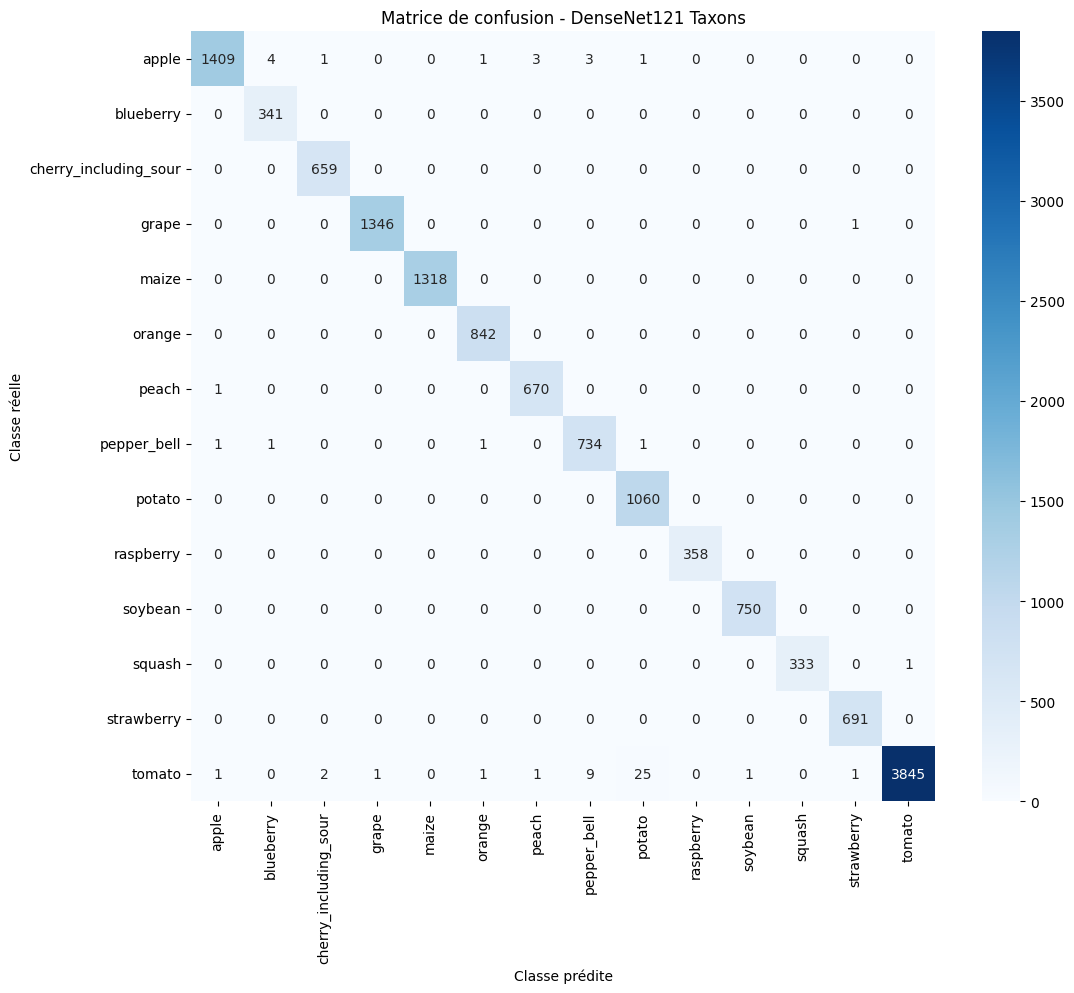

In [ ]:
# ============================================================
# 21. MATRICE DE CONFUSION
# ============================================================


cm = confusion_matrix(
    y_true,
    y_pred)

class_names = encoder.classes_

plt.figure(
    figsize=(12,10))

sns.heatmap(

    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d")

plt.xlabel(
    "Classe prédite")


plt.ylabel(
    "Classe réelle")


plt.title(
    "Matrice de confusion - DenseNet121 Taxons")


plt.xticks(
    rotation=90)


plt.yticks(
    rotation=0)


plt.show()

### Visualisation maivaises prédictions

In [ ]:
# ============================================================
# 22. ERREURS DE CLASSIFICATION
# ============================================================



erreurs = np.where(
    y_true != y_pred
)[0]

print(
    f"Nombre d'erreurs : {len(erreurs)}")

plt.figure(
    figsize=(15,15))

for i, idx in enumerate(erreurs[:9]):


    plt.subplot(
        3,
        3,
        i+1)
    img_path = df_test.iloc[idx]["chemin"]


    img = Image.open(
        img_path)

    plt.imshow(
        img)

    vrai = encoder.inverse_transform(
        [y_true[idx]])[0]

    pred = encoder.inverse_transform(
        [y_pred[idx]]
    )[0]
    plt.title(
        f"Vrai : {vrai}\nPrédit : {pred}",
        fontsize=9)
    plt.axis(
        "off")

plt.tight_layout()

plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Grad CAM

In [ ]:

!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 144.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=e56f79f53e70bf7c56dc4a65857eab79622815355f0853bc866352b41698a6fe
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.model_targets import (
    ClassifierOutputTarget)

from pytorch_grad_cam.utils.image import (
    show_cam_on_image)

In [ ]:

images, labels = next(
    iter(dataloader_test))

img = images[0].unsqueeze(0).to(
    device)

label = labels[0]

prediction = model(
    img)

classe_predite = torch.argmax(
    prediction,
    dim=1
).item()

print(
    "Classe réelle :",
    encoder.classes_[label])
print(
    "Classe prédite :",
    encoder.classes_[classe_predite])

Classe réelle : apple
Classe prédite : apple


In [ ]:

target_layers = [

    model.features.denseblock4]

cam = GradCAM(

    model=model,

    target_layers=target_layers)
targets = [

    ClassifierOutputTarget(
        classe_predite)]
grayscale_cam = cam(
    input_tensor=img,
    targets=targets)

grayscale_cam = grayscale_cam[0]

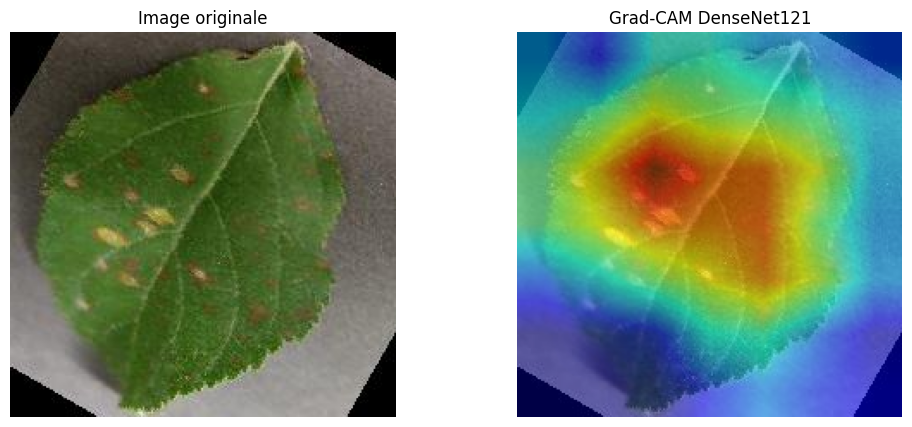

In [ ]:


img_display = images[0].permute(
    1,
    2,
    0
).numpy()



mean = np.array(
    [0.485,
        0.456,
        0.406])

std = np.array(
    [0.229,
        0.224,
        0.225])

img_display = (
    std * img_display
    + mean)
img_display = np.clip(
    img_display,
    0,
    1)

visualization = show_cam_on_image(

    img_display,

    grayscale_cam,

    use_rgb=True)
plt.figure(
    figsize=(12,5))

plt.subplot(
    1,
    2,
    1)
plt.imshow(
    img_display)
plt.title(
    "Image originale")

plt.axis(
    "off")

plt.subplot(
    1,
    2,
    2)
plt.imshow(
    visualization)
plt.title(
    "Grad-CAM DenseNet121")
plt.axis(
    "off")
plt.show()

In [ ]:
# Pour 10 classes:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# Récupération d'une image
images, labels = next(
    iter(dataloader_test)
)

img = images[0].unsqueeze(0).to(device)

label = labels[0]


# Prédiction
prediction = model(img)

classe_predite = torch.argmax(
    prediction,
    dim=1
).item()


print(
    "Classe réelle :",
    encoder.classes_[label]
)

print(
    "Classe prédite :",
    encoder.classes_[classe_predite]
)



# Couche cible DenseNet121
target_layers = [
    model.features.denseblock4
]


cam = GradCAM(
    model=model,
    target_layers=target_layers
)



# Dé-normalisation image
img_display = images[0].permute(
    1,
    2,
    0
).numpy()


mean = np.array(
    [0.485, 0.456, 0.406]
)

std = np.array(
    [0.229, 0.224, 0.225]
)


img_display = (
    std * img_display
    + mean
)


img_display = np.clip(
    img_display,
    0,
    1
)



# Nombre de classes
num_classes = len(encoder.classes_)



plt.figure(
    figsize=(15, 12)
)



# Image originale
plt.subplot(
    3,
    4,
    1
)


plt.imshow(
    img_display
)


plt.title(
    "Image originale\n"
    + encoder.classes_[label]
)


plt.axis(
    "off"
)



# Grad-CAM pour les 10 classes
for class_idx in range(num_classes):

    targets = [
        ClassifierOutputTarget(class_idx)
    ]


    grayscale_cam = cam(
        input_tensor=img,
        targets=targets
    )[0]


    visualization = show_cam_on_image(
        img_display,
        grayscale_cam,
        use_rgb=True
    )


    plt.subplot(
        3,
        4,
        class_idx + 2
    )


    plt.imshow(
        visualization
    )


    plt.title(
        f"{class_idx} : {encoder.classes_[class_idx]}"
    )


    plt.axis(
        "off"
    )



plt.tight_layout()
plt.show()